In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("insurance.csv")

In [ ]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [ ]:
df.shape

(1340, 10)

In [ ]:
pd.set_option("display.float_format","{:.2f}".format)

In [ ]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

**DATA CLEANING- EDA AND DATA VALIDATION**

In [ ]:
df.duplicated().sum() #it counts all the unique row in the dataset,
# o/p being 0 means there are 0 duplicated row values in the system


np.int64(0)

In [ ]:
df.isna().sum() # this checks if any NA value is there, returns false if a valid value is there otherwise true

,0
Id,0
age,5
gender,0
bmi,0
bloodpressure,0
diabetic,0
children,0
smoker,0
region,3
claim,0


In [ ]:
df.dropna() #drops all the NA values from the dataset temporarily

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [ ]:
df.dropna(inplace=True) #drops them permanently

In [ ]:
df.shape

(1332, 10)

**NUMERICAL DISTRIBUTION HISTOGRAM**

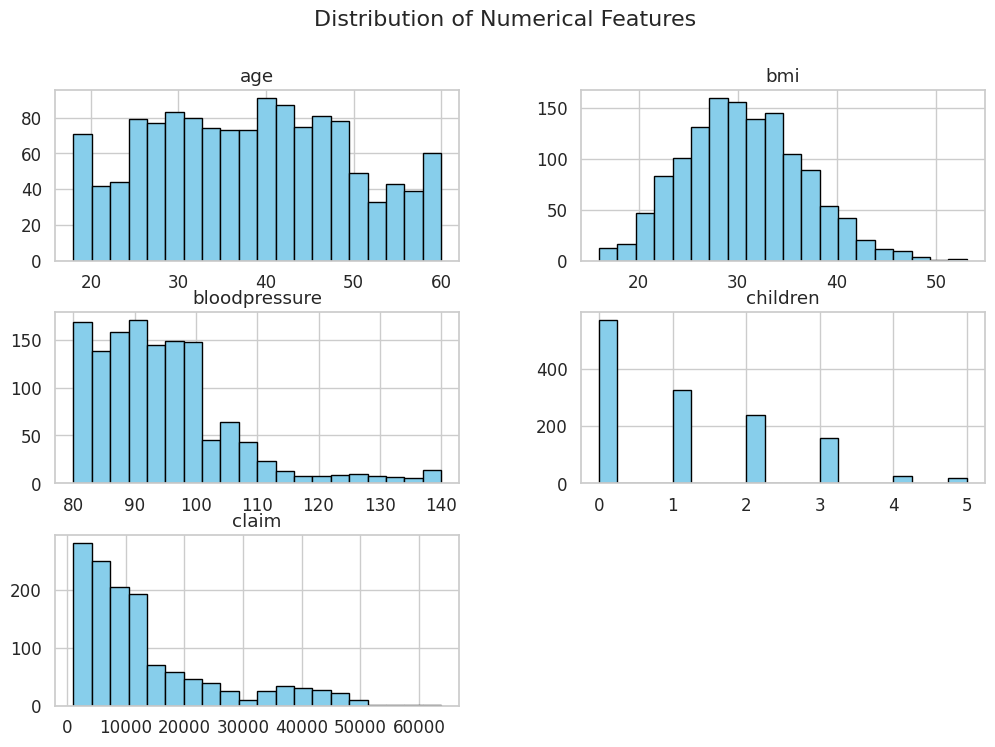

In [ ]:
numeric_cols= ["age", "bmi", "bloodpressure", "children", "claim"]
df[numeric_cols].hist(bins=20, figsize=(12,8), color= "skyblue", edgecolor= "black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

**CATEGORICAL DISTRIBUTION**

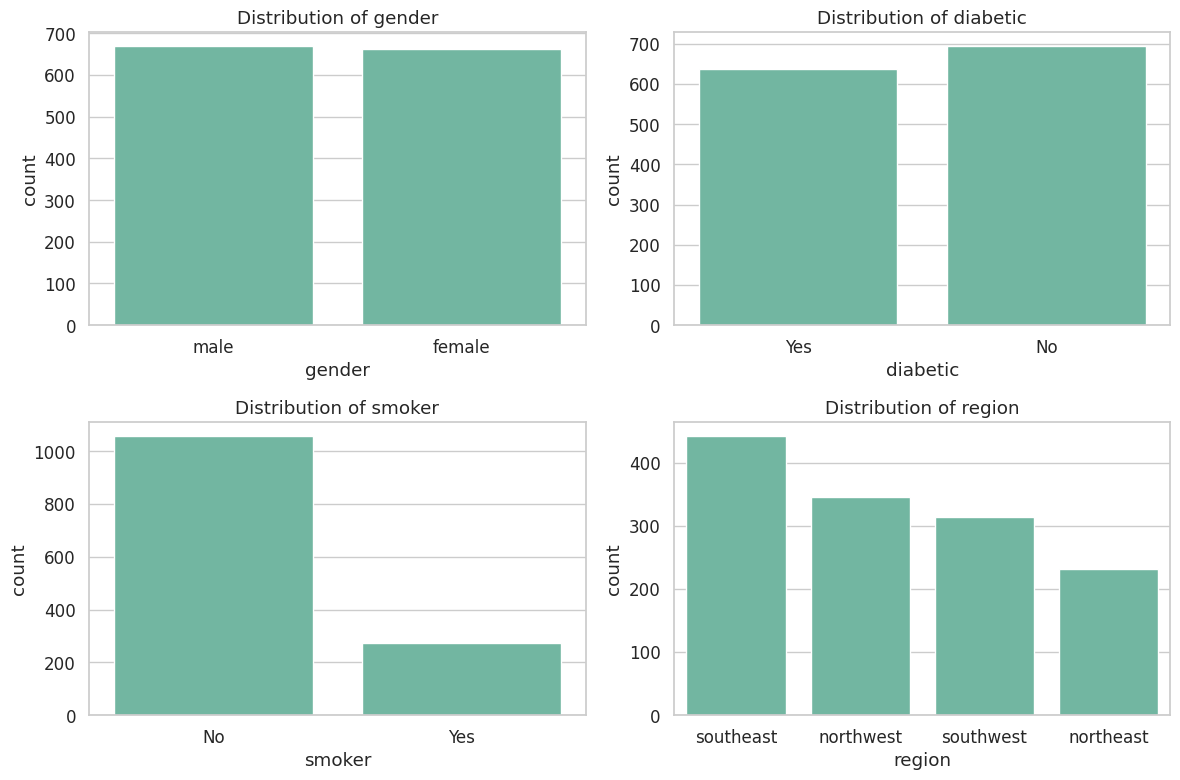

In [ ]:
cat_cols=["gender", "diabetic", "smoker", "region"]

plt.figure(figsize=(12,8)) #width, height

for i,col in enumerate(cat_cols, 1):
  plt.subplot(2,2,i)
  sns.countplot(data= df, x=col)
  plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [ ]:
df.groupby(["gender","smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

**DATA VISUALIZATION**

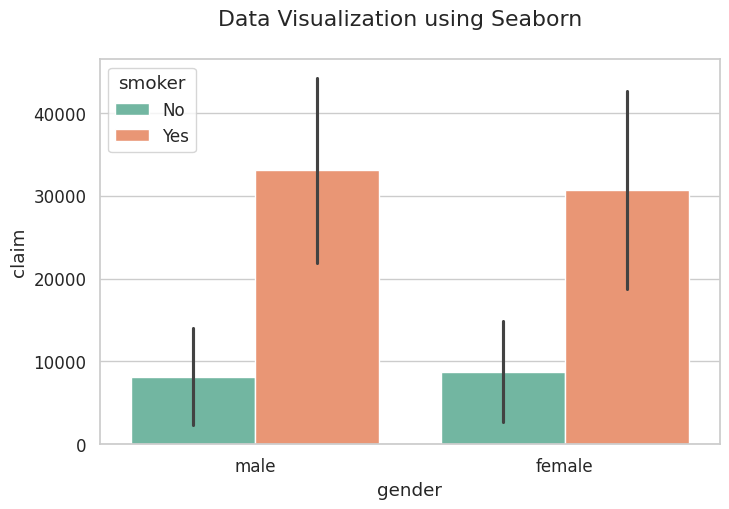

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="gender", y="claim", hue="smoker", estimator="mean", errorbar="sd") # sd means standard deviation which is represented through the vertical line in the botton
plt.suptitle("Data Visualization using Seaborn")
plt.show()

In [ ]:
pivot_table=pd.pivot_table(df, values="claim", index="region", columns="smoker", aggfunc="mean")
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [ ]:
pivot_table=pd.pivot_table(df, values="claim", index="children", columns="diabetic", aggfunc="mean") #avg of children based on diabetic
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


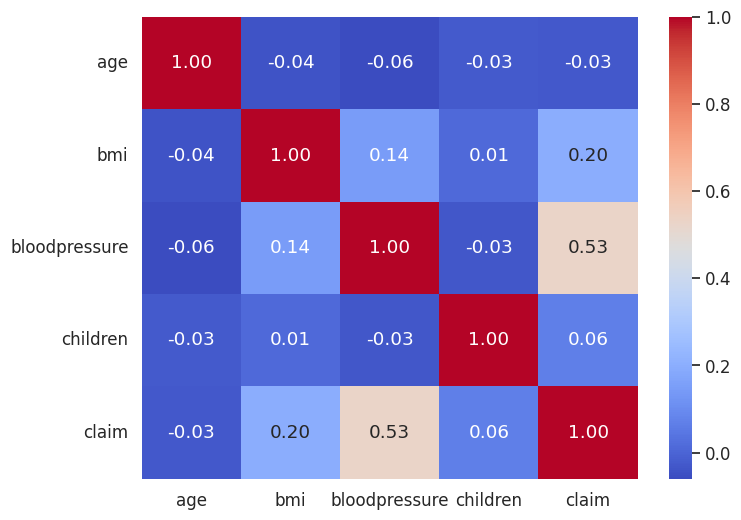

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

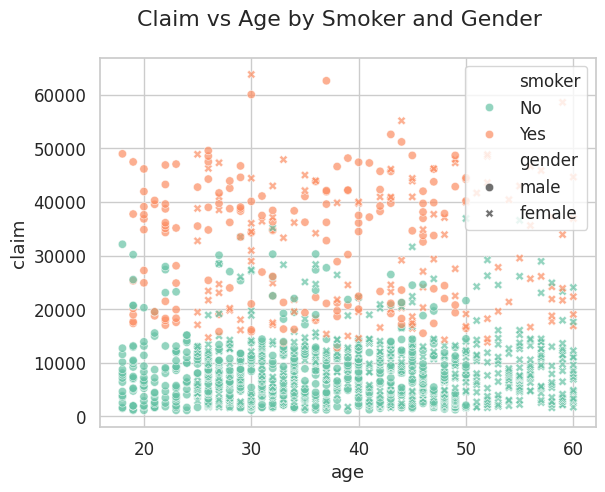

In [ ]:
sns.scatterplot(data=df, x="age", y="claim", hue="smoker", style="gender", alpha=0.7)
plt.suptitle("Claim vs Age by Smoker and Gender")
plt.show() #multivariate scatterplot

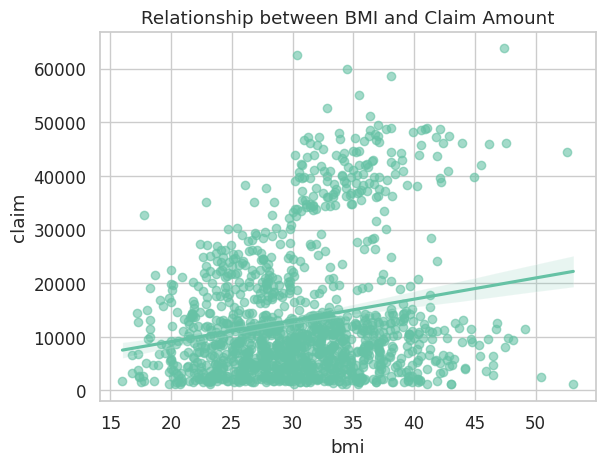

In [ ]:
sns.regplot(data=df, x="bmi", y="claim", scatter_kws={"alpha":0.6})
plt.title("Relationship between BMI and Claim Amount")
plt.show()

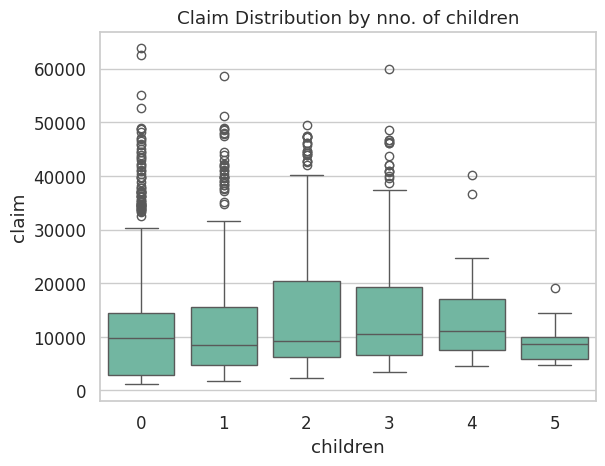

In [ ]:
#children vs claim
sns.boxplot(data=df, x="children", y="claim")
plt.title("Claim Distribution by nno. of children")
plt.show()

**DATA PREPROCESSING**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [ ]:
df=df.dropna()
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim'],
      dtype='object')

In [ ]:
X= df[["age", "gender", "bmi", "bloodpressure", "diabetic", "children", "smoker"]].copy()
Y= df["claim"]

In [ ]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.0,male,23.2,91,Yes,0,No
1,24.0,male,30.1,87,No,0,No
7,19.0,male,41.1,100,No,0,No
8,20.0,male,43.0,86,No,0,No
9,30.0,male,53.1,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.0,female,35.5,88,Yes,0,Yes
1336,59.0,female,38.1,120,No,1,Yes
1337,30.0,male,34.5,91,Yes,3,Yes
1338,37.0,male,30.4,106,No,0,Yes


In [ ]:
cat_cols= ["gender", "diabetic", "smoker"]
label_encoders={}

In [ ]:
for col in cat_cols:
  le= LabelEncoder()
  X[col]= le.fit_transform(X[col])
  label_encoders[col]= le

  joblib.dump(le, f"label_encoder_{col}.pkl")

In [ ]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.0,1,23.2,91,1,0,0
1,24.0,1,30.1,87,0,0,0
7,19.0,1,41.1,100,0,0,0
8,20.0,1,43.0,86,0,0,0
9,30.0,1,53.1,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.0,0,35.5,88,1,0,1
1336,59.0,0,38.1,120,0,1,1
1337,30.0,1,34.5,91,1,3,1
1338,37.0,1,30.4,106,0,0,1


In [ ]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [ ]:
X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2)

In [ ]:
num_cols= ["age", "bmi", "bloodpressure", "children"]
scaler= StandardScaler()

In [ ]:
X_train[num_cols]= scaler.fit_transform(X_train[num_cols])
X_test[num_cols]= scaler.transform(X_test[num_cols])

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
print(X_train.shape, Y_train.shape)

(1065, 7) (1065,)


In [ ]:
print(X_test.shape, Y_test.shape)

(267, 7) (267,)


**TRAINING MACHINE LEARNING MODEL**

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [ ]:
#for regression problem

def evaluate_model(model, X_train, X_test, Y_train, Y_test):
  Y_pred= model.predict(X_test)
  r2= r2_score(Y_test, Y_pred)
  mae= mean_absolute_error(Y_test, Y_pred)
  rmse= np.sqrt(mean_squared_error(Y_test, Y_pred))
  return {"R2": r2, "MAE": mae, "RMSE": rmse}

In [ ]:
#defining the dict to store results

results= {}

In [ ]:
#Model Training coding


lr= LinearRegression()
lr.fit(X_train, Y_train)
results["Linear Regression"]= evaluate_model(lr, X_train, X_test, Y_train, Y_test)
print("Linear Regression model trained")

#polynomial degree regression
best_poly_model= None
best_poly_score= -np.inf

for degree in [2,3]:
  poly= PolynomialFeatures(degree= degree)
  X_train_poly= poly.fit_transform(X_train)
  X_test_poly= poly.transform(X_test)

  poly_lr= LinearRegression()
  poly_lr.fit(X_train_poly, Y_train)

  score= poly_lr.score(X_test_poly, Y_test)

  if score> best_poly_score:

    best_poly_score= score
    best_poly_model= (degree, poly, poly_lr)

degree, poly, poly_lr= best_poly_model

results[f"Polynomial Regression (deg= {degree})"]= evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), Y_train, Y_test)

print("Polynomial Regression models are trained")

#RandomForestRegressor
rf= RandomForestRegressor()

rf_param= {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

rf_grid= GridSearchCV(rf, rf_param, cv=3, scoring="r2", n_jobs=-1, verbose=0)
rf_grid.fit(X_train, Y_train)
best_rf= rf_grid.best_estimator_

results["Random Forest"]= evaluate_model(best_rf, X_train, X_test, Y_train, Y_test)

print("Random Forest training is done, best parameters", rf_grid.best_params_)

#Support Vector Regressor
svr= SVR()

svr_param= {
    "kernel": ["rbf", "poly", "linear"],
    "C": [1,10,50],
    "epsilon": [0.1, 0.2, 0.5],
    "degree": [2,3]
}

svr_grid= GridSearchCV(svr, svr_param, cv=3, scoring="r2", n_jobs= -1, verbose=0)
svr_grid.fit(X_train, Y_train)

best_svr= svr_grid.best_estimator_

results["SVR"]= evaluate_model(best_svr, X_train, X_test, Y_train, Y_test)

print("SVR training done", "best param :", svr_grid.best_params_)

#XGBoost

xgb= XGBRegressor(objective= "reg:squarederror")

xgb_param= {
    "n_estimators": [100,200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid= GridSearchCV(xgb, xgb_param, cv=3, scoring= "r2", n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, Y_train)

best_xgb= xgb_grid.best_estimator_

results["XGBoost"]= evaluate_model(best_xgb, X_train, X_test,Y_train, Y_test)

print("XGBoost training done", "best parameters:", xgb_grid.best_params_)


Linear Regression model trained
Polynomial Regression models are trained
Random Forest training is done, best parameters {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
SVR training done best param : {'C': 50, 'degree': 2, 'epsilon': 0.5, 'kernel': 'linear'}
XGBoost training done best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [ ]:
results

{'Linear Regression': {'R2': 0.7549121892698601,
  'MAE': 4788.662952919491,
  'RMSE': np.float64(6444.021705135156)},
 'Polynomial Regression (deg= 3)': {'R2': 0.7914910666966382,
  'MAE': 4434.8788759568115,
  'RMSE': np.float64(5943.721770114851)},
 'Random Forest': {'R2': 0.8446428993194258,
  'MAE': 3759.2636264074026,
  'RMSE': np.float64(5130.523629779827)},
 'SVR': {'R2': 0.5099142781386243,
  'MAE': 6270.861477671062,
  'RMSE': np.float64(9112.38715784823)},
 'XGBoost': {'R2': 0.8386378483079773,
  'MAE': 3847.5425135328887,
  'RMSE': np.float64(5228.739151461796)}}

In [ ]:
results_df= pd.DataFrame(results).T.sort_values(by="R2", ascending= False)

results_df

,R2,MAE,RMSE
Random Forest,0.844643,3759.263626,5130.523630
XGBoost,0.838638,3847.542514,5228.739151
Polynomial Regression (deg= 3),0.791491,4434.878876,5943.721770
Linear Regression,0.754912,4788.662953,6444.021705
SVR,0.509914,6270.861478,9112.387158


In [ ]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "Random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [ ]:
best_r2= results_df["R2"].max()

best_r2

0.8446428993194258

In [ ]:
top_model= results_df[results_df["R2"]== best_r2]

top_model

,R2,MAE,RMSE
Random Forest,0.844643,3759.263626,5130.52363


In [ ]:
best_model= models[top_model.index[0]]

best_model

RandomForestRegressor(max_depth=10, min_samples_leaf=2)

In [ ]:
joblib.dump(best_model, "best_model.pkl")

print(f"Best model selected: {top_model.index[0]}")

Best model selected: Random Forest
